In [23]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [24]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [25]:
IN_double_mutation = "C140D-D148B"
pair1, pair2 = functions.split_pairs(IN_double_mutation)
wt1,pos1,mt1 = functions.split_pair(pair1)
wt2,pos2,mt2 = functions.split_pair(pair2)
IN_seq_w_mutation = [seq for seq in IN_all_seq if seq[pos1-1] == mt1 and seq[pos2-1] == mt2]
print(len(IN_seq_w_mutation))

221


In [26]:
p_SH_all = [functions.calculate_double_mutant_probablity(seq, 'C140D', 'D148B', IN_J, 1, 263) for seq in IN_seq_w_mutation]
lowest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__)[:10]
highest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__, reverse=True)[:10]

print("10 lowest probability indices:", lowest_prob_indices)
print("10 highest probability indices:", highest_prob_indices)


10 lowest probability indices: [47, 4, 25, 19, 44, 216, 203, 219, 43, 123]
10 highest probability indices: [172, 193, 55, 92, 210, 70, 0, 88, 190, 74]


In [27]:
min_position = 1
max_position = 263

print("Lowest probability indices and values:", [(i, p_SH_all[i]) for i in lowest_prob_indices])
print("Highest probability indices and values:", [(i, p_SH_all[i]) for i in highest_prob_indices])

Lowest probability indices and values: [(47, 0.007800793463008116), (4, 0.028399198721585844), (25, 0.03629026601253644), (19, 0.05293623759243532), (44, 0.061805707433160474), (216, 0.06347403329018718), (203, 0.08040587285169684), (219, 0.09282344926178461), (43, 0.09960123704315765), (123, 0.1073738893249246)]
Highest probability indices and values: [(172, 0.9920179375618225), (193, 0.9916040563588459), (55, 0.9907137598656011), (92, 0.9865013227062998), (210, 0.985960115614258), (70, 0.9767480412742192), (0, 0.9730512870129445), (88, 0.9729018823109195), (190, 0.9721211738209948), (74, 0.9661677256170271)]


In [ ]:
vectors_top10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
vectors_bottom10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
print(sum(vectors_top10[0])/2)
print(sum(vectors_bottom10[0])/2)

with open('top_bottom_vectors.txt', 'w') as f:
    f.write("TOP_VECTORS\n")
    for v in vectors_top10:
        f.write(repr([float(x) for x in v]) + "\n")

    f.write("\nBOTTOM_VECTORS\n")
    for v in vectors_bottom10:
        f.write(repr([float(x) for x in v]) + "\n")

print("Wrote top_bottom_vectors.txt")

-1553.3956
-1530.8302
Wrote top_bottom_vectors.txt


In [29]:
# # verify vectorization on consensus sequence
# consensus_E = functions.calculate_e(IN_consensus_seq, IN_J, min_position, max_position)
# print(consensus_E)

# consensus_residue_E_vector = functions.vectorize_seq_residue_energy(IN_consensus_seq, IN_J, min_position, max_position)
# print(sum(consensus_residue_E_vector)/2)


In [30]:
# #verify E values for top and bottom sequences
# E_top10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
# E_bottom10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
# print("E values for top 10 highest probability sequences:", E_top10)
# print("E values for top 10 lowest probability sequences:", E_bottom10)

Explained variance ratio: [0.16889992 0.10484719]


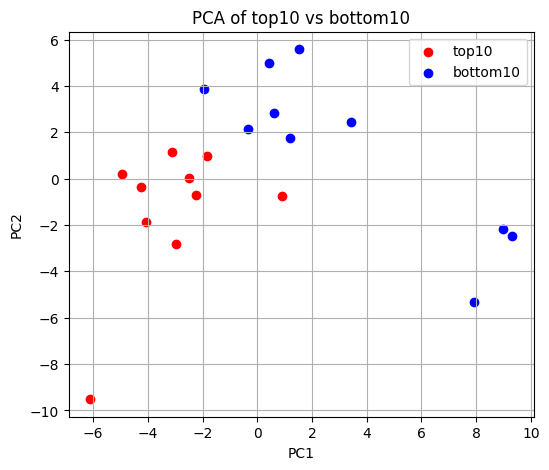

In [31]:
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

X_top = np.array(vectors_top10)
X_bot = np.array(vectors_bottom10)
X = np.vstack([X_top, X_bot])
labels = np.array([1]*len(X_top) + [0]*len(X_bot))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[labels==1,0], X_pca[labels==1,1], c='r', label='top10')
plt.scatter(X_pca[labels==0,0], X_pca[labels==0,1], c='b', label='bottom10')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.title('PCA of top10 vs bottom10'); plt.grid(True)
plt.show()

# pc1 = pca.components_[0]
# print("PC1 eigenvector shape:", pc1.shape)
# print("PC1 eigenvector:", pc1)

Explained variance ratio (one-hot): [0.1287735  0.11035827 0.09436509]


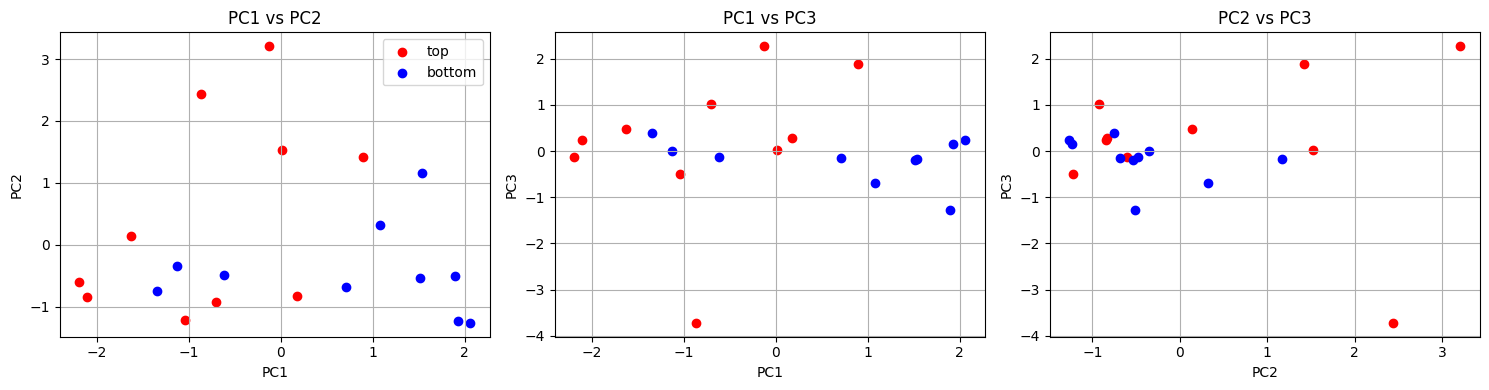

In [34]:
# One-hot encode sequences (per-residue) and run PCA on most/least probable sequences

# select sequences
top_seqs = [IN_seq_w_mutation[i] for i in highest_prob_indices]
bot_seqs = [IN_seq_w_mutation[i] for i in lowest_prob_indices]

# build alphabet from available sequences to ensure proper mapping
alphabet = sorted({ch for seq in IN_all_seq for ch in seq})
char2idx = {ch: idx for idx, ch in enumerate(alphabet)}
L = len(top_seqs[0])  # sequence length
K = len(alphabet)     # one-hot depth

def seq_one_hot_flat(seq):
    mat = np.zeros((L, K), dtype=np.float32)
    for j, ch in enumerate(seq):
        mat[j, char2idx[ch]] = 1.0
    return mat.ravel()

X_top_ohe = np.vstack([seq_one_hot_flat(s) for s in top_seqs])
X_bot_ohe = np.vstack([seq_one_hot_flat(s) for s in bot_seqs])
X_ohe = np.vstack([X_top_ohe, X_bot_ohe])
labels_ohe = np.array([1]*len(X_top_ohe) + [0]*len(X_bot_ohe))

pca_ohe = PCA(n_components=3)
Xo_pca = pca_ohe.fit_transform(X_ohe)
print("Explained variance ratio (one-hot):", pca_ohe.explained_variance_ratio_)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(Xo_pca[labels_ohe==1,0], Xo_pca[labels_ohe==1,1], c='r', label='top')
plt.scatter(Xo_pca[labels_ohe==0,0], Xo_pca[labels_ohe==0,1], c='b', label='bottom')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PC1 vs PC2'); plt.legend(); plt.grid(True)

plt.subplot(1,3,2)
plt.scatter(Xo_pca[labels_ohe==1,0], Xo_pca[labels_ohe==1,2], c='r')
plt.scatter(Xo_pca[labels_ohe==0,0], Xo_pca[labels_ohe==0,2], c='b')
plt.xlabel('PC1'); plt.ylabel('PC3'); plt.title('PC1 vs PC3'); plt.grid(True)

plt.subplot(1,3,3)
plt.scatter(Xo_pca[labels_ohe==1,1], Xo_pca[labels_ohe==1,2], c='r')
plt.scatter(Xo_pca[labels_ohe==0,1], Xo_pca[labels_ohe==0,2], c='b')
plt.xlabel('PC2'); plt.ylabel('PC3'); plt.title('PC2 vs PC3'); plt.grid(True)

plt.tight_layout()
plt.show()

X_trans.shape: (526, 10)
Explained variance ratio: [0.6541856  0.07536391]


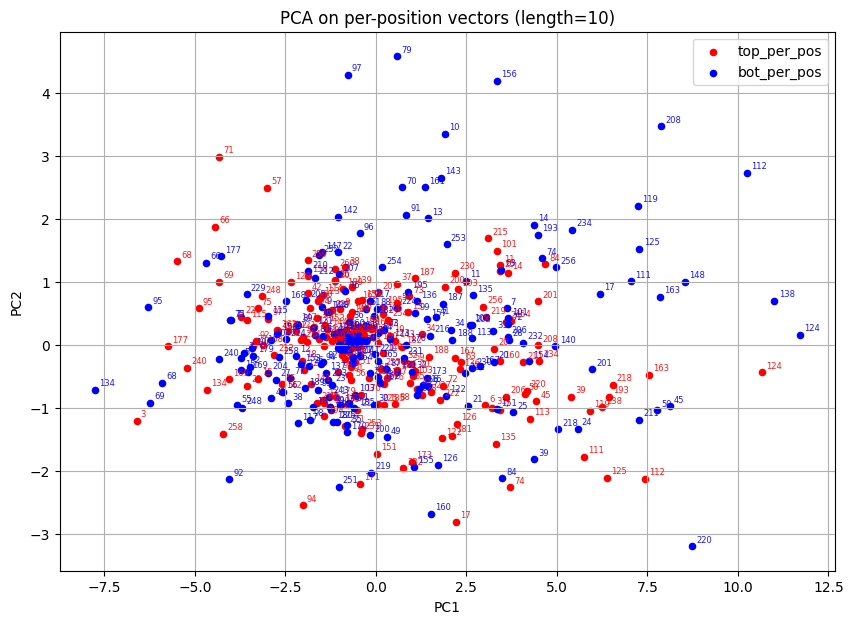

In [32]:
# Build per-position vectors of length 10 for top and bottom groups, then run PCA
data_top = X_top.T              # shape: (max_position, 10)
data_bot = X_bot.T              # shape: (max_position, 10)

X_trans = np.vstack([data_top, data_bot])   # shape: (max_position*2, 10)
labels_trans = np.array([1]*max_position + [0]*max_position)

pca2 = PCA(n_components=2)
X_trans_pca = pca2.fit_transform(X_trans)

print("X_trans.shape:", X_trans.shape)
print("Explained variance ratio:", pca2.explained_variance_ratio_)

plt.figure(figsize=(10,7))
plt.scatter(X_trans_pca[labels_trans==1,0], X_trans_pca[labels_trans==1,1], c='r', s=20, label='top_per_pos')
plt.scatter(X_trans_pca[labels_trans==0,0], X_trans_pca[labels_trans==0,1], c='b', s=20, label='bot_per_pos')

# annotate each point with its position index (1-based, using min_position)
for i, (x,y) in enumerate(X_trans_pca):
    pos = (i % max_position) + min_position
    col = 'r' if labels_trans[i]==1 else 'b'
    plt.annotate(str(pos), xy=(x,y), xytext=(3,3), textcoords='offset points',
                 fontsize=6, color=col, alpha=0.9)

plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.title('PCA on per-position vectors (length=10)'); plt.grid(True)
plt.show()